# Data Science Camp 2026  
## Task 1

## Task Description

Generate a sequence of 26 random integer values in the range from 0 to 26.
Build a plot that connects each neighbouring value, similar to the example
provided for the sample sequence:

[2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17,
7, 5, 20, 17, 18, 10]

Consider these values as heights of two-dimensional mountains on which
rain falls from above. Subsections of the sequence that have higher values
at their boundaries form lakes.

### Objectives:
1. Develop a function that accepts a list of 26 integer values and calculates
   the depth of the deepest lake.
   For the provided sample, the expected result is 20, which corresponds
   to the lake formed by the subsequence [23, 14, 1, 8, 1, 8, 16, 21].
2. Visualize the values as mountain heights and highlight the deepest lake.

The solution must be implemented using programming code in a Jupyter
Notebook, Google Colab, or a similar environment, and must include:
1. Generation of a list of 26 random integer values,
2. A function that calculates the depth of the deepest lake,
3. The result of the calculation for the provided sample of 26 integers,
4. Visualization of the data with the deepest lake highlighted.


## Libraries Used
- `random` — generate random integers  
- `matplotlib.pyplot` — visualization


In [2]:
import random
import matplotlib.pyplot as plt


## Generating random data

First, a sequence of 26 random integer values is generated.
Each value represents the height of a mountain at a specific position.


In [3]:
random_values = [random.randint(0, 26) for _ in range(26)]
print("Random values:", random_values)


Random values: [4, 22, 5, 7, 13, 14, 13, 12, 16, 24, 25, 2, 17, 5, 13, 8, 20, 4, 0, 6, 11, 8, 3, 1, 8, 5]


## Provided sample sequence

The following sequence is given in the task description.
It is used to validate the correctness of the algorithm.

For this sample, the expected deepest lake depth is 20.


In [4]:
sample = [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]

## Finding the deepest lake

To solve the problem, a function is implemented that analyzes the height sequence
and determines the deepest lake.

The function calculates:
- the water level between mountain boundaries,
- the depth at each position,
- and selects the deepest lake according to a fixed rule.


In [5]:
def deepest_lake(values):
    n = len(values)
    if n < 3:
        return 0, None, None, None

    # max to the left / right
    left_max = [0] * n
    right_max = [0] * n

    left_max[0] = values[0]
    for i in range(1, n):
        left_max[i] = max(left_max[i - 1], values[i])

    right_max[n - 1] = values[n - 1]
    for i in range(n - 2, -1, -1):
        right_max[i] = max(right_max[i + 1], values[i])

    # water level and depth at each index
    water_level = [min(left_max[i], right_max[i]) for i in range(n)]
    depth = [max(0, water_level[i] - values[i]) for i in range(n)]

    max_depth = max(depth)
    if max_depth == 0:
        return 0, None, None, None

    # if several lakes have the same maximum depth,
    # the first one is selected
    i0 = depth.index(max_depth)
    level = water_level[i0]

    # find lake boundaries around that point
    l = i0
    while l > 0 and values[l] < level:
        l -= 1

    r = i0
    while r < n - 1 and values[r] < level:
        r += 1

    if l == r or values[l] < level or values[r] < level:
        return max_depth, None, None, level

    return max_depth, l, r, level


## Check sample result 

In [6]:
# check sample result
depth, l, r, level = deepest_lake(sample)

print("Deepest lake depth (sample):", depth)
print("Boundaries (l, r):", (l, r))
print("Water level:", level)

if l is not None and r is not None:
    print("Subsequence:", sample[l:r+1])
else:
    print("Subsequence: None")

# optional quick check from the task statement
assert depth == 20, "Sample check failed: expected 20"


Deepest lake depth (sample): 20
Boundaries (l, r): (2, 10)
Water level: 23
Subsequence: [25, 14, 14, 21, 20, 6, 13, 3, 23]


## Plot function with highlighted deepest lake
### also added saving results here

In [10]:
def plot_with_deepest_lake(values, title="Heights with deepest lake highlighted"):
    # find the deepest lake and its boundaries
    max_depth, l, r, level = deepest_lake(values)
    x = list(range(len(values)))

    # draw the main height plot
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, linewidth=2)

    if l is not None and r is not None:
        # highlight the deepest lake
        plt.plot(x[l:r+1], values[l:r+1], linewidth=3)

        # draw water level and lake bottom
        bottom = min(values[l+1:r]) if r - l >= 2 else values[l]
        plt.axhline(level, linestyle="--", alpha=0.6)
        plt.axhline(bottom, linestyle="--", alpha=0.6)

    # plot labels and title
    plt.title(f"{title} | deepest depth = {max_depth}")
    plt.xlabel("Index")
    plt.ylabel("Height")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{title.replace(' ', '_').lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
# save results to txt
with open("task1_results.txt", "w") as f:
    f.write(f"Sample depth: {depth}\n")
    f.write(f"Sample boundaries: ({l}, {r})\n")
    f.write(f"Sample water level: {level}\n")
    f.write(f"Sample subsequence: {sample[l:r+1]}\n\n")

    rd, rl, rr, rlvl = deepest_lake(random_values)
    f.write(f"Random depth: {rd}\n")
    f.write(f"Random boundaries: ({rl}, {rr})\n")
    f.write(f"Random water level: {rlvl}\n")
    f.write(f"Random subsequence: {random_values[rl:rr+1] if rl is not None else None}\n")

## Visualization for the provided sample

The provided sample sequence is visualized below.
The deepest lake is highlighted, and dashed lines indicate:
- the water level (top),
- the lowest point inside the lake (bottom).

Deepest lake depth (sample): 20
Boundaries (l, r): (2, 10)
Water level: 23
Subsequence: [25, 14, 14, 21, 20, 6, 13, 3, 23]


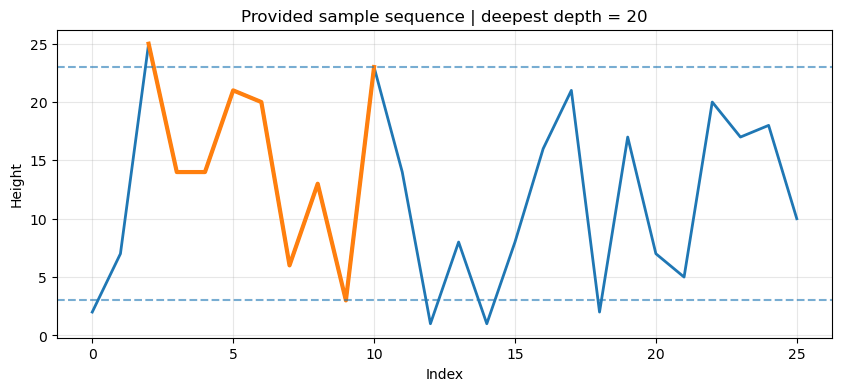

In [8]:
depth, l, r, level = deepest_lake(sample)

print("Deepest lake depth (sample):", depth)
print("Boundaries (l, r):", (l, r))
print("Water level:", level)

# print the lake subsequence if it exists
if l is not None and r is not None:
    print("Subsequence:", sample[l:r+1])
else:
    print("Subsequence: None")

plot_with_deepest_lake(sample, title="Provided sample sequence")

## Visualization for a random sequence

The same approach is applied to a randomly generated sequence
to demonstrate that the algorithm works for arbitrary data.


Deepest lake depth (random): 18
Boundaries (l, r): (10, 16)
Water level: 20
Subsequence: [25, 2, 17, 5, 13, 8, 20]


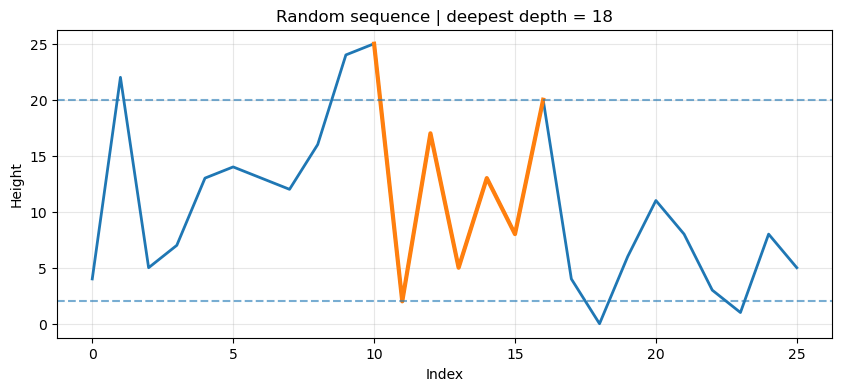

In [9]:
depth, l, r, level = deepest_lake(random_values)

print("Deepest lake depth (random):", depth)
print("Boundaries (l, r):", (l, r))
print("Water level:", level)

# print the lake subsequence if it exists
if l is not None and r is not None:
    print("Subsequence:", random_values[l:r+1])
else:
    print("Subsequence: None")

plot_with_deepest_lake(random_values, title="Random sequence")


## Conclusion

In this task, a sequence of heights was analyzed to find the deepest lake
formed between higher values.

The implemented function correctly finds the deepest lake in the provided
sample, where the depth equals 20, as required in the task.

The same approach was also applied to a randomly generated sequence,
and the result was successfully visualized.
